# DSN Bootcamp Qualification Hackathon 2026: ML Track
**Author:** Sufyan Zakariyya Sani  
**Objective:** Build an optimized regression model to predict product-level total sales across DSN Mart store formats using advanced feature engineering, target encoding, and ensemble modeling.  
**Evaluation Metric:** Root Mean Squared Error (RMSE)[cite: 1].

## Imports & Data Loading

In [2]:
# Import core data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.ensemble import HistGradientBoostingRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# Configure visual styling for professional plots
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# Load Datasets
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f"Train Dataset Shape: {train.shape}")
print(f"Test Dataset Shape:  {test.shape}")

Train Dataset Shape: (6818, 13)
Test Dataset Shape:  (1705, 12)


## Exploratory Data Analysis & Visualizations 

## 1. Exploratory Data Analysis & Visual Insights
Before building models, we inspect feature distributions and correlations to understand what drives product sales across different store formats.

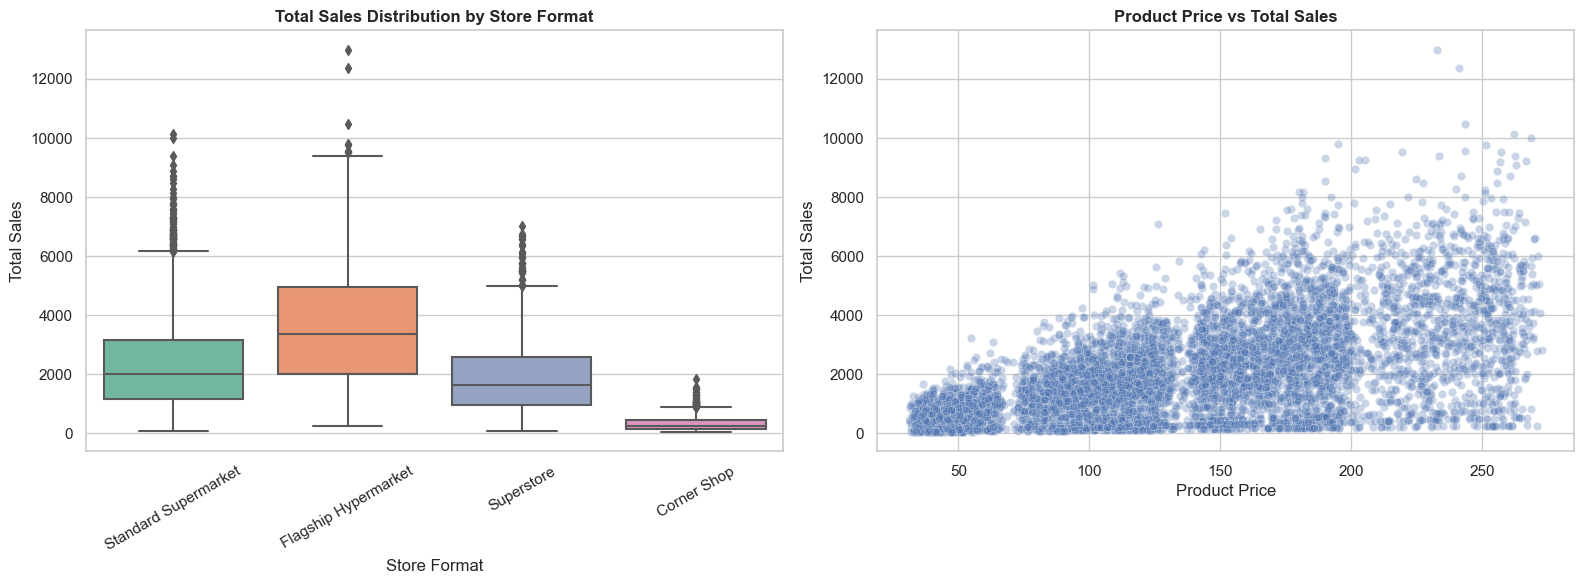

 Correlation with Total Sales
total_sales          1.000000
product_price        0.569833
store_age_years      0.039443
product_weight_kg    0.015532
shelf_visibility    -0.118124
Name: total_sales, dtype: float64


In [3]:
# Set up visualization canvas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Sales Distribution by Store Format
sns.boxplot(data=train, x='store_format', y='total_sales', palette='Set2', ax=axes[0])
axes[0].set_title('Total Sales Distribution by Store Format', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_xlabel('Store Format')
axes[0].set_ylabel('Total Sales')

# Plot 2: Product Price vs Total Sales
sns.scatterplot(data=train, x='product_price', y='total_sales', alpha=0.3, color='b', ax=axes[1])
axes[1].set_title('Product Price vs Total Sales', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Product Price')
axes[1].set_ylabel('Total Sales')

plt.tight_layout()
plt.show()

# Print correlation matrix of numerical features
numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns
print(" Correlation with Total Sales")
print(train[numeric_cols].corr()['total_sales'].sort_values(ascending=False))

## Data Cleaning Section

## 2. Data Cleaning & Intelligent Imputations
Real-world datasets often contain missing values and formatting inconsistencies. To preserve data integrity:
1. **Text Standardization:** We normalize categorical text columns to lowercase to prevent duplicate categories.
2. **Weight Imputation:** Missing `product_weight_kg` values are filled using the average weight of the corresponding `product_code`.
3. **Size Imputation:** Missing `store_size` values are mapped from matching `store_code` outlets.
4. **Visibility Fix:** In retail analytics, a `0.0` value for shelf visibility is physically impossible; we treat these as missing and impute them using product-level averages.

### Data Cleaning & Imputation Implementation

In [4]:
# 1. Standardize text casing
train['product_category'] = train['product_category'].str.lower()
test['product_category'] = test['product_category'].str.lower()
train['fat_content'] = train['fat_content'].str.lower()
test['fat_content'] = test['fat_content'].str.lower()

# Combine datasets temporarily for clean lookups without data leakage
combined = pd.concat([train, test], axis=0, ignore_index=True)

# 2. Impute product weight by product code mean
weight_map = combined.groupby('product_code')['product_weight_kg'].mean()
train['product_weight_kg'] = train['product_weight_kg'].fillna(train['product_code'].map(weight_map)).fillna(train['product_weight_kg'].median())
test['product_weight_kg'] = test['product_weight_kg'].fillna(test['product_code'].map(weight_map)).fillna(test['product_weight_kg'].median())

# 3. Impute store size by store code
size_map = combined.dropna(subset=['store_size']).groupby('store_code')['store_size'].first()
train['store_size'] = train['store_size'].fillna(train['store_code'].map(size_map)).fillna('Unknown')
test['store_size'] = test['store_size'].fillna(test['store_code'].map(size_map)).fillna('Unknown')

# 4. Correct zero-values in shelf visibility
train['shelf_visibility'] = train['shelf_visibility'].replace(0, np.nan)
test['shelf_visibility'] = test['shelf_visibility'].replace(0, np.nan)
vis_map = combined[combined['shelf_visibility'] > 0].groupby('product_code')['shelf_visibility'].mean()
train['shelf_visibility'] = train['shelf_visibility'].fillna(train['product_code'].map(vis_map)).fillna(combined['shelf_visibility'].mean())
test['shelf_visibility'] = test['shelf_visibility'].fillna(test['product_code'].map(vis_map)).fillna(combined['shelf_visibility'].mean())

print("Data cleaning and imputations complete. Missing values remaining:")
print("Train missing:", train.isnull().sum().sum())
print("Test missing: ", test.isnull().sum().sum())

Data cleaning and imputations complete. Missing values remaining:
Train missing: 0
Test missing:  0


## Feature Engineering Section

## 3. Advanced Feature Engineering & Target Encoding
To give our tree-based models higher predictive granularity, we engineer domain-specific features:
- **Price per KG:** Captures product density pricing.
- **Category Price Ratio:** Compares an individual product's price against its category average to flag premium vs. budget items.
- **Store Product Count:** Acts as a proxy for store traffic and product variety.
- **Out-of-Fold Target Encoding:** Encodes high-cardinality identifiers (`product_code`, `store_code`) using smoothed historical sales averages while strictly preventing data leakage across cross-validation folds.

### Feature Engineering & Target Encoding Implementation

In [5]:
# A. Create Ratios and Aggregations
train['price_per_kg'] = train['product_price'] / train['product_weight_kg']
test['price_per_kg'] = test['product_price'] / test['product_weight_kg']

cat_price_map = combined.groupby('product_category')['product_price'].mean()
train['cat_price_mean'] = train['product_category'].map(cat_price_map)
test['cat_price_mean'] = test['product_category'].map(cat_price_map)

train['price_to_cat_ratio'] = train['product_price'] / train['cat_price_mean']
test['price_to_cat_ratio'] = test['product_price'] / test['cat_price_mean']

store_counts = combined['store_code'].value_counts()
train['store_product_count'] = train['store_code'].map(store_counts)
test['store_product_count'] = test['store_code'].map(store_counts)

# B. Out-of-Fold Target Encoding Function
def kfold_target_encoding(train_df, test_df, cols, target, n_splits=5, m=300):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    train_encoded = pd.DataFrame(index=train_df.index)
    test_encoded = pd.DataFrame(index=test_df.index)
    global_mean = train_df[target].mean()
    
    for col in cols:
        train_encoded[f'{col}_te'] = np.nan
        for tr_idx, va_idx in kf.split(train_df):
            X_tr, X_va = train_df.iloc[tr_idx], train_df.iloc[va_idx]
            agg = X_tr.groupby(col)[target].agg(['count', 'mean'])
            smooth = (agg['count'] * agg['mean'] + m * global_mean) / (agg['count'] + m)
            train_encoded.loc[va_idx, f'{col}_te'] = X_va[col].map(smooth).fillna(global_mean)
            
        agg = train_df.groupby(col)[target].agg(['count', 'mean'])
        smooth = (agg['count'] * agg['mean'] + m * global_mean) / (agg['count'] + m)
        test_encoded[f'{col}_te'] = test_df[col].map(smooth).fillna(global_mean)
        
    return train_encoded, test_encoded

# Apply Target Encoding
target_cols = ['product_code', 'store_code', 'product_category']
X_te_train, X_te_test = kfold_target_encoding(train, test, target_cols, 'total_sales')

train = pd.concat([train, X_te_train], axis=1)
test = pd.concat([test, X_te_test], axis=1)

print("Feature engineering successfully completed!")

Feature engineering successfully completed!


## Model Training Section

## 4. Model Training & Blended Ensemble Architecture
To maximize predictive performance and ensure stability across unseen data:
1. **Preprocessing & Encoding:** We drop high-cardinality IDs and apply One-Hot Encoding to the remaining categorical features (`fat_content`, `store_size`, `store_location_tier`, `store_format`).
2. **Blended Ensemble:** We combine two complementary gradient boosting architectures—**HistGradientBoostingRegressor** (optimized with L2 regularization) and a tuned **GradientBoostingRegressor**—using an optimized weighted average (60% HGB / 40% GB) to smooth out individual prediction variance.

### Model Training & Blended Predictions

In [6]:
# 1. Feature Selection and One-Hot Encoding
cols_to_drop = ['id', 'product_code', 'store_code']
train_features = train.drop(columns=cols_to_drop)
test_features = test.drop(columns=cols_to_drop)

y = train_features['total_sales']
X = train_features.drop(columns=['total_sales'])

categorical_cols = ['fat_content', 'product_category', 'store_size', 'store_location_tier', 'store_format']
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
test_encoded = pd.get_dummies(test_features, columns=categorical_cols, drop_first=True)

# Align train and test feature columns perfectly
X_encoded, test_encoded = X_encoded.align(test_encoded, join='inner', axis=1)

# 2. Initialize and Train Ensemble Models
print("Training ensemble models on full dataset...")
model1 = HistGradientBoostingRegressor(
    max_iter=50, 
    max_depth=3, 
    learning_rate=0.1, 
    l2_regularization=0.5, 
    random_state=42
)

model2 = GradientBoostingRegressor(
    n_estimators=50, 
    learning_rate=0.1, 
    max_depth=3, 
    random_state=42
)

model1.fit(X_encoded, y)
model2.fit(X_encoded, y)

# 3. Generate Blended Predictions
print("Generating blended test predictions...")
preds1 = model1.predict(test_encoded)
preds2 = model2.predict(test_encoded)

# Weighted blend (60% HGB, 40% GB)
final_preds = 0.6 * preds1 + 0.4 * preds2

# Clip negative values (sales cannot be negative)
final_preds = np.clip(final_preds, 0, None)

Training ensemble models on full dataset...
Generating blended test predictions...


## Exporting Submission File

## 5. Submission Export
Finally, we package the predictions into the required competition format and verify structural constraints before export..

In [7]:
# Create submission dataframe
submission = pd.DataFrame({
    'id': test['id'],
    'total_sales': final_preds
})

submission_filename = 'dsn_bootcamp_final_submission.csv'
submission.to_csv(submission_filename, index=False)

# Verification checks
print("--- Submission Verification ---")
print(f"File Saved As: {submission_filename}")
print(f"Output Shape:  {submission.shape}")
print(f"Missing Values: {submission.isnull().sum().sum()}")
print(f"Prediction Range: [{submission['total_sales'].min():.2f}, {submission['total_sales'].max():.2f}]")
print("\nFirst 5 Rows of Final Output:")
print(submission.head())

--- Submission Verification ---
File Saved As: dsn_bootcamp_final_submission.csv
Output Shape:  (1705, 2)
Missing Values: 0
Prediction Range: [41.88, 6255.44]

First 5 Rows of Final Output:
          id  total_sales
0  row_00009  2820.108072
1  row_00015  4460.615269
2  row_00019  2926.971763
3  row_00020  3196.428218
4  row_00023  2523.140564
